# Assessments 분석

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
# 폰트 테마 설정
sns.set_theme(style="whitegrid")
# 한글 폰트 설정 (맑은 고딕) — set_theme 이후에 지정해야 덮어쓰이지 않음
plt.rc("font", family="Malgun Gothic")
# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 1. 데이터 불러오기

In [58]:
assess = pd.read_csv("../CSV_files/assessments.csv")
st_assess = pd.read_csv("../CSV_files/studentAssessment.csv")

print(assess.head())
print(st_assess.head())

  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0
3         AAA             2013J           1755             TMA  166.0    20.0
4         AAA             2013J           1756             TMA  215.0    30.0
   id_assessment  id_student  date_submitted  is_banked  score
0           1752       11391              18          0   78.0
1           1752       28400              22          0   70.0
2           1752       31604              17          0   72.0
3           1752       32885              26          0   69.0
4           1752       38053              19          0   79.0


In [59]:
print(assess.info())
print(st_assess.info())

<class 'pandas.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    str    
 1   code_presentation  206 non-null    str    
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    str    
 4   date               195 non-null    float64
 5   weight             206 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 9.8 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_assessment   173912 non-null  int64  
 1   id_student      173912 non-null  int64  
 2   date_submitted  173912 non-null  int64  
 3   is_banked       173912 non-null  int64  
 4   score           173739 non-null  float64
dtypes: float64(1), int64(4)
memory usa

In [60]:
print(assess.describe())
print(st_assess.describe())

       id_assessment        date      weight
count     206.000000  195.000000  206.000000
mean    26473.975728  145.005128   20.873786
std     10098.625521   76.001119   30.384224
min      1752.000000   12.000000    0.000000
25%     15023.250000   71.000000    0.000000
50%     25364.500000  152.000000   12.500000
75%     34891.750000  222.000000   24.250000
max     40088.000000  261.000000  100.000000
       id_assessment    id_student  date_submitted      is_banked  \
count  173912.000000  1.739120e+05   173912.000000  173912.000000   
mean    26553.803556  7.051507e+05      116.032942       0.010977   
std      8829.784254  5.523952e+05       71.484148       0.104194   
min      1752.000000  6.516000e+03      -11.000000       0.000000   
25%     15022.000000  5.044290e+05       51.000000       0.000000   
50%     25359.000000  5.852080e+05      116.000000       0.000000   
75%     34883.000000  6.344980e+05      173.000000       0.000000   
max     37443.000000  2.698588e+06      608

In [61]:
print(assess.isnull().sum())
print(st_assess.isnull().sum())

code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64
id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64


## 1. assessments.csv : 교수님의 과제 계획서

- code_module / code_presentation: 우리가 이미 마스터한 과목 코드(예: AAA)와 학기 정보(예: 2013J)예요.

- id_assessment (과제 고유 번호): 과제 시험지마다 붙어 있는 ID 

- assessment_type (과제 유형): 과제의 종류예요. TMA는 튜터(선생님)가 직접 채점하는 리포트, CMA는 컴퓨터가 자동으로 채점하는 온라인 퀴즈, Exam은 최종 시험을 뜻해요.

- date (과제 마감일): 학기가 정식 시작하고 몇 일째 되는 날까지 과제를 내야 하는지 기준일

- weight (성적 반영 비율): 이 과제가 최종 학점에 몇 %나 반영되는지 나타내는 배점 가중치

## 2. studentAssessment.csv : 수강생들의 실제 성적표


- id_assessment / id_student: 어떤 학생(id_student)이 어떤 과제 시험지(id_assessment)를 냈는지 확인하는 연결고리에요.

- date_submitted (실제 제출일): 학생이 실제로 과제 버튼을 누른 날짜예요. 교수님의 마감일(date)보다 숫자가 크면 지연 제출

- is_banked (점수 이월 여부): 1이면 예전에 낙제했다가 재수강하면서 과거에 잘 받아둔 과제 점수를 그대로 인정받아 이월했다는 뜻, 0이면 이번 학기에 새로 제출했다는 뜻.

- score (과제 점수): 0점부터 100점까지 수강생이 실제로 획득한 점수.

# 2. label_churn 정의 (이전 노트북과 동일한 기준)

01, 02번 노트북과 이탈 기준을 통일해서 비교할 수 있도록, 여기서도 studentInfo.csv를 불러와
동일한 규칙(Withdrawn=이탈, 나머지=완수)으로 label_churn을 만들어두고 앞으로 계속 재사용합니다.

In [62]:
info = pd.read_csv("../CSV_files/studentInfo.csv")

# 01_Student_info_EDA.ipynb, 02_EDA_Student_Registration.ipynb와 동일한 기준입니다.
# 훈련 결과가 'Withdrawn'이면 "이탈", 나머지(Pass/Fail/Distinction)는 "완수"로 분류합니다.
info["label_churn"] = info["final_result"].apply(lambda x: "이탈" if x == "Withdrawn" else "완수")

# 결과가 어떻게 나뉘었는지 퍼센트로 확인합니다. (이전 노트북과 같은 값(완수 0.688 / 이탈 0.312)이 나와야 정상입니다)
print(info["label_churn"].value_counts(normalize=True).round(3))

label_churn
완수    0.688
이탈    0.312
Name: proportion, dtype: float64


# 3. 데이터 품질 검증

본격적으로 분석하기 전에, 두 테이블의 결측치와 특이값들이 어떤 의미인지 먼저 파악해둡니다.
제대로 확인하지 않고 넘어가면 나중에 "제출 지연일수" 같은 파생 변수를 만들 때 결과가
왜곡될 수 있습니다.

### 3-1. assessment_type별 결측/누락 확인

assessments.csv의 date(마감일) 결측 11건과, studentAssessment.csv에 제출 기록 자체가 없는
평가가 있는지 assessment_type별로 확인합니다.

In [63]:
# 1) 평가 유형(TMA/CMA/Exam) 구성 확인
print("assessment_type 분포:")
print(assess["assessment_type"].value_counts())

# 2) date(마감일)가 결측인 11건이 어떤 유형인지 확인
print("\ndate 결측 11건의 assessment_type:")
print(assess[assess["date"].isna()]["assessment_type"].value_counts())

# 3) 참조 무결성: studentAssessment의 id_assessment가 assessments.csv에 다 있는지 확인
missing_ids = set(st_assess["id_assessment"]) - set(assess["id_assessment"])
print("\nstudentAssessment에만 있고 assessments엔 없는 id_assessment 수:", len(missing_ids))

# 4) 반대로 assessments엔 있는데 studentAssessment엔 제출 기록이 하나도 없는 평가 확인
no_submission_ids = set(assess["id_assessment"]) - set(st_assess["id_assessment"])
print("\n제출 기록이 하나도 없는 평가 수:", len(no_submission_ids))
print(assess[assess["id_assessment"].isin(no_submission_ids)]["assessment_type"].value_counts())

assessment_type 분포:
assessment_type
TMA     106
CMA      76
Exam     24
Name: count, dtype: int64

date 결측 11건의 assessment_type:
assessment_type
Exam    11
Name: count, dtype: int64

studentAssessment에만 있고 assessments엔 없는 id_assessment 수: 0

제출 기록이 하나도 없는 평가 수: 18
assessment_type
Exam    18
Name: count, dtype: int64


**[확인 결과]** date 결측 11건은 **전부 Exam**이고, 제출 기록이 아예 없는 평가 18건도 **전부 Exam**입니다
(전체 Exam 24개 중 18개, 75%). 참조 무결성은 문제없음(0건)을 확인했습니다.

즉 studentAssessment.csv는 사실상 **TMA/CMA(과제형 평가)** 위주의 데이터이고, **기말시험(Exam)은
대부분 이 파일에 기록되어 있지 않습니다.** 이후 분석에서 "과제 점수/제출 패턴"을 볼 때는 이 파일이
유효하지만, "기말 성적 전체"를 보고 싶다면 studentInfo의 final_result를 따로 참고해야 합니다.

### 3-2. score 결측 173건 확인

score가 비어 있는 173건이 is_banked(이월 점수)와 관련 있는지 확인합니다.

In [64]:
print("score 결측 173건의 is_banked 분포:")
print(st_assess[st_assess["score"].isna()]["is_banked"].value_counts())

score 결측 173건의 is_banked 분포:
is_banked
0    172
1      1
Name: count, dtype: int64


**[확인 결과]** score 결측 173건 중 172건이 is_banked=0(이월이 아닌 일반 제출)입니다.
즉 이월 점수와는 무관하고, 제출은 했지만 아직 채점(또는 기록)이 안 된 경우로 보입니다.
전체 173,912건 중 0.1%로 비중이 아주 작아서, 분석에 큰 영향은 없습니다.

### 3-3. is_banked와 date_submitted의 관계 확인

date_submitted가 음수(마감일 이전 제출)인 2,057건이 있는데, 이 중 상당수가 실제 제출일이
아니라 "이월 처리"를 의미하는 플레이스홀더 값은 아닌지 확인합니다.

In [65]:
neg = st_assess[st_assess["date_submitted"] < 0]
print("date_submitted < 0 인 건수:", len(neg))
print("이 중 is_banked 분포:")
print(neg["is_banked"].value_counts())

# is_banked=1(이월) 레코드의 date_submitted 값이 전부 동일한지(=진짜 제출일이 아닌 placeholder인지) 확인
banked = st_assess[st_assess["is_banked"] == 1]
print("\nis_banked=1인 레코드의 date_submitted 분포:")
print(banked["date_submitted"].describe())

date_submitted < 0 인 건수: 2057
이 중 is_banked 분포:
is_banked
1    1909
0     148
Name: count, dtype: int64

is_banked=1인 레코드의 date_submitted 분포:
count    1909.0
mean       -1.0
std         0.0
min        -1.0
25%        -1.0
50%        -1.0
75%        -1.0
max        -1.0
Name: date_submitted, dtype: float64


**[확인 결과]** is_banked=1인 1,909건은 **date_submitted가 예외 없이 전부 -1**입니다(표준편차 0).
즉 -1은 실제 제출일이 아니라 "이월 점수라서 제출일 자체가 의미 없다"는 뜻의 플레이스홀더 값입니다.

반면 나머지 148건(음수이지만 is_banked=0)은 마감일보다 최대 11일 먼저 낸 진짜 조기 제출 기록입니다.

**[결론 — 이후 분석에 반영할 사항]**
1. "제출 지연일수"나 "조기/지연 제출" 같은 파생 변수를 만들 때는 **is_banked=1 레코드를 반드시
   제외**해야 합니다. 안 그러면 이월 점수 1,909건이 전부 "11일 조기 제출"로 잘못 계산됩니다.
2. Exam 유형은 이 파일에서 사실상 다루기 어려우므로, 과제(TMA/CMA) 중심으로 분석을 진행합니다.
3. score 결측(0.1%)은 무시 가능한 수준입니다.

# 4. 제출 지연일수(delay_days) 파생 변수 생성

3번에서 확인한 대로 is_banked=1(이월) 레코드와 date(마감일)가 없는(Exam) 레코드를 제외하고,
assessments와 studentAssessment를 조인해서 "마감일 대비 며칠 만에 냈는지(delay_days)"를
계산합니다. 양수면 지연 제출, 0 이하면 제때 또는 조기 제출입니다.

In [66]:
# 1) is_banked=1(이월 점수) 레코드 제외 — date_submitted가 -1로 고정된 가짜 값이기 때문
st_valid = st_assess[st_assess["is_banked"] == 0].copy()

# 2) assessments와 조인해서 마감일(date), 배점(weight) 정보를 붙입니다.
merged_assess = pd.merge(st_valid, assess, on="id_assessment", how="left")

# 3) date(마감일)가 없는 레코드(대부분 Exam) 제외 — 마감일이 없으면 지연 여부를 계산할 수 없습니다.
merged_assess = merged_assess.dropna(subset=["date"]).copy()

# 4) 지연일수 계산: 실제 제출일 - 마감일. 양수=지연, 0=제때, 음수=조기 제출
merged_assess["delay_days"] = merged_assess["date_submitted"] - merged_assess["date"]

print("분석 대상 건수:", len(merged_assess), "/ 원본", len(st_assess), "건")
print()
print(merged_assess["delay_days"].describe())

merged_assess["is_late"] = merged_assess["delay_days"] > 0
print("\n전체 지연 제출 비율:", round(merged_assess["is_late"].mean() * 100, 1), "%")

분석 대상 건수: 169138 / 원본 173912 건

count    169138.000000
mean        -15.865382
std          44.962846
min        -246.000000
25%          -6.000000
50%          -1.000000
75%           2.000000
max         372.000000
Name: delay_days, dtype: float64

전체 지연 제출 비율: 29.2 %


### 4-1. delay_days 값이 이상하게 널뛰는 이유 확인 (weight=0 문제)

delay_days 최댓값이 372일까지 나와서, 이게 진짜 이상치인지 확인해봅니다. 그런데 assessments.csv에는
**weight(배점 가중치)가 0인 평가가 56개**나 있습니다 — 최종 성적에 전혀 반영되지 않는 연습용 문제라는
뜻입니다. 이런 문제는 학생이 마감일을 신경 쓰지 않고 편할 때 풀어볼 가능성이 높으므로, weight>0인
실제 채점 대상 과제와 분리해서 봐야 합니다.

In [67]:
print("weight=0(연습용, 성적 미반영) 평가 개수:", (assess["weight"] == 0).sum(), "/", len(assess))

print("\n[weight=0] 지연일수 분포:")
print(merged_assess[merged_assess["weight"] == 0]["delay_days"].describe())

print("\n[weight>0, 실제 채점 대상] 지연일수 분포:")
print(merged_assess[merged_assess["weight"] > 0]["delay_days"].describe())

print("\nweight 유무에 따른 지연(>0) 비율 비교:")
print(merged_assess.groupby(merged_assess["weight"] == 0)["delay_days"].apply(lambda x: (x > 0).mean() * 100).round(1))

weight=0(연습용, 성적 미반영) 평가 개수: 56 / 206

[weight=0] 지연일수 분포:
count    46742.000000
mean       -58.402786
std         68.690036
min       -246.000000
25%        -98.000000
50%        -28.000000
75%         -5.000000
max        372.000000
Name: delay_days, dtype: float64

[weight>0, 실제 채점 대상] 지연일수 분포:
count    122396.000000
mean          0.379293
std           6.078729
min        -141.000000
25%          -1.000000
50%           0.000000
75%           2.000000
max         198.000000
Name: delay_days, dtype: float64

weight 유무에 따른 지연(>0) 비율 비교:
weight
False    37.5
True      7.4
Name: delay_days, dtype: float64


**[정정]** 처음엔 "weight=0인 연습용 과제가 지연률을 부풀렸을 것"이라 예상했는데, 실제로는 **반대**였습니다.

- **weight=0(연습용)**: 지연 비율 **7.4%**로 오히려 낮지만, 평균 -58.4일 · 표준편차 68.7일로 마감일과
  무관하게 훨씬 일찍 풀어보거나(중앙값 -28일) 가끔 몇 달씩 늦게 복습 삼아 풀어보는 등 편차가 아주 큽니다.
- **weight>0(실제 채점 대상)**: 지연 비율이 오히려 **37.5%**로 훨씬 높고, 평균 +0.4일 · 표준편차 6.1일로
  마감일 바로 근처(며칠 이내)에 몰려 있습니다.

즉 실제 성적에 반영되는 과제일수록 마감일을 딱 맞춰 내려다 오히려 살짝 늦는 경우가 잦고, 성적과
무관한 연습 문제는 늦더라도 폭이 클 뿐 "마감을 넘겼다"고 판단되는 경우 자체는 적었던 것입니다.

**[결론]** 이후 "제출 지연이 이탈과 관련 있는가"를 분석할 때는 **weight > 0인 과제만** 사용해야
실제 학사 일정과 관련된 의미 있는 지연 신호를 볼 수 있습니다.

# 5. 완수/이탈 그룹별 점수·제출 패턴 비교 (핵심 분석)

지금까지 정리한 것(is_banked 제외, weight>0만 사용)을 바탕으로, studentInfo의 label_churn과
조인해서 "과제를 잘 챙기는 것이 이탈과 관련 있는가"를 직접 확인합니다. 점수, 제출 지연,
과제 제출률(참여도) 세 가지 관점에서 봅니다.

In [68]:
# label_churn을 (id_student, code_module, code_presentation) 3개 키로 조인합니다.
# id_student만으로 조인하면 재수강생(같은 학생이 여러 과목/학기를 들은 경우) 때문에 잘못 매칭될 수 있어
# 반드시 3개 키를 모두 맞춰야 합니다.
full = pd.merge(
    merged_assess,
    info[["id_student", "code_module", "code_presentation", "label_churn"]],
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)
print("조인 후 label_churn 결측 수:", full["label_churn"].isna().sum(), "/", len(full))

# 4-1에서 확인한 대로 weight>0(실제 채점 대상)만 사용합니다.
w = full[full["weight"] > 0].copy()

조인 후 label_churn 결측 수: 0 / 169138


### 5-1. 완수/이탈 그룹별 평균 점수

             mean  median   std   count
label_churn                            
완수           75.8    79.0  18.1  111183
이탈           64.9    68.0  22.5   11049


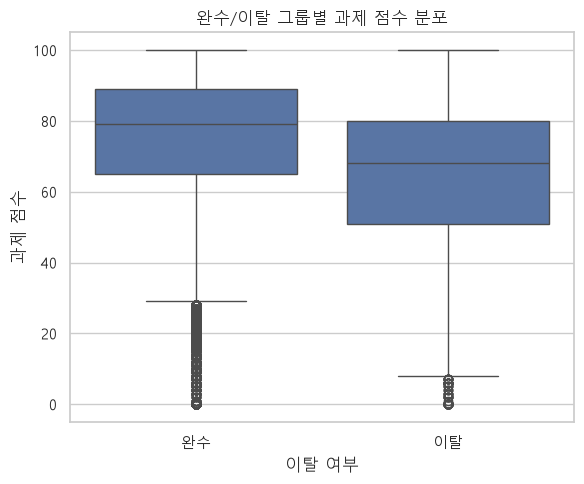

In [69]:
print(w.groupby("label_churn")["score"].agg(["mean", "median", "std", "count"]).round(1))

plt.figure(figsize=(6, 5))
sns.boxplot(data=w, x="label_churn", y="score")
plt.title("완수/이탈 그룹별 과제 점수 분포")
plt.xlabel("이탈 여부")
plt.ylabel("과제 점수")
plt.tight_layout()
plt.show()

# [해석 포인트] 이탈 그룹의 평균 점수(64.9점)가 완수 그룹(75.8점)보다 약 11점 낮습니다.
# 이탈하기 전까지 제출한 과제만 놓고 봐도, 이미 성취도가 낮은 상태였다는 뜻입니다.

### 5-2. 완수/이탈 그룹별 제출 지연 비교

              지연률  평균지연일
label_churn             
완수           36.5   0.25
이탈           47.0   1.71


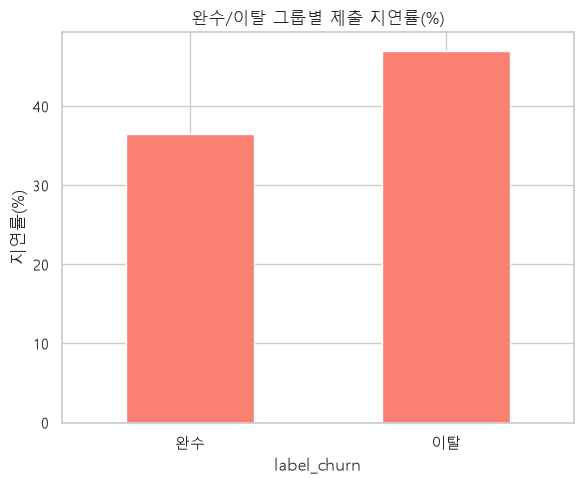

In [70]:
late_summary = w.groupby("label_churn").agg(지연률=("is_late", "mean"), 평균지연일=("delay_days", "mean"))
late_summary["지연률"] = (late_summary["지연률"] * 100).round(1)
late_summary["평균지연일"] = late_summary["평균지연일"].round(2)
print(late_summary)

plt.figure(figsize=(6, 5))
late_summary["지연률"].plot(kind="bar", color="salmon")
plt.title("완수/이탈 그룹별 제출 지연률(%)")
plt.ylabel("지연률(%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# [해석 포인트] 이탈 그룹의 지연률(47.0%)이 완수 그룹(36.5%)보다 뚜렷하게 높습니다.
# 평균 지연일수도 이탈 그룹이 1.71일로 완수 그룹(0.25일)의 약 7배입니다.

### 5-3. 완수/이탈 그룹별 과제 제출률(참여도)

지금까지는 "제출한 과제"만 대상으로 점수/지연을 봤습니다. 이번엔 관점을 바꿔서, 학생이 애초에
"내야 할 과제 중 몇 %를 실제로 냈는지"를 계산합니다. 아예 제출하지 않은 것까지 포함해야 진짜
참여도를 알 수 있기 때문입니다.

             mean  median  count
label_churn                     
완수           62.3    80.0  22437
이탈           13.6     0.0  10156

과제를 단 하나도 내지 않은(제출률 0%) 학생 비율:
label_churn
완수    15.8
이탈    57.4
Name: submission_rate, dtype: float64


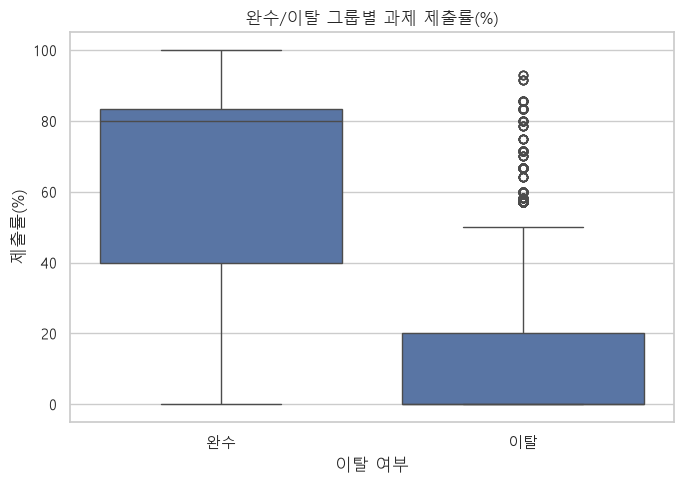

In [71]:
# 학생별로 실제 제출한 weight>0 과제 개수
sub_count = w.groupby(["id_student", "code_module", "code_presentation"]).size().reset_index(name="submitted_cnt")

# 과목/학기별로 배정된 weight>0 과제 개수 (=이 강좌를 들으면 원래 내야 하는 과제 수)
expected_cnt = assess[assess["weight"] > 0].groupby(["code_module", "code_presentation"]).size().reset_index(name="expected_cnt")

# info(수강생별 1행)를 기준으로 실제 제출 개수와 배정 개수를 붙여서 제출률을 계산합니다.
course_level = info[["id_student", "code_module", "code_presentation", "label_churn"]].drop_duplicates()
course_level = pd.merge(course_level, sub_count, on=["id_student", "code_module", "code_presentation"], how="left")
course_level["submitted_cnt"] = course_level["submitted_cnt"].fillna(0)  # 제출 기록이 아예 없으면 0건
course_level = pd.merge(course_level, expected_cnt, on=["code_module", "code_presentation"], how="left")
course_level["submission_rate"] = course_level["submitted_cnt"] / course_level["expected_cnt"] * 100

print(course_level.groupby("label_churn")["submission_rate"].agg(["mean", "median", "count"]).round(1))

zero_rate = course_level.groupby("label_churn")["submission_rate"].apply(lambda x: (x == 0).mean() * 100).round(1)
print("\n과제를 단 하나도 내지 않은(제출률 0%) 학생 비율:")
print(zero_rate)

plt.figure(figsize=(7, 5))
sns.boxplot(data=course_level, x="label_churn", y="submission_rate")
plt.title("완수/이탈 그룹별 과제 제출률(%)")
plt.xlabel("이탈 여부")
plt.ylabel("제출률(%)")
plt.tight_layout()
plt.show()

**[1차 발견 — 그런데 그대로 믿기 전에 검증이 필요합니다]**
- 완수 그룹의 평균 제출률은 62.3%(중앙값 80%)인데, **이탈 그룹은 평균 13.6%, 중앙값 0%**입니다.
- **제출률 0%인 학생 비율이 완수 그룹은 15.8%인데 이탈 그룹은 57.4%**로, 거의 4배 차이입니다.

다만 이 수치를 그대로 "이탈 학생은 원래 과제를 안 낸다"로 해석하면 안 됩니다. **이탈 학생은
정의상 강좌를 끝까지 듣지 않고 중간에 나간 학생**입니다. expected_cnt는 강좌 전체 기간의
과제 개수를 기준으로 계산했기 때문에, 학생이 탈퇴한 **이후에 마감되는 과제**까지 "안 낸 것"으로
잡혔을 가능성이 있습니다 — 이건 게을러서가 아니라 애초에 낼 수 없었던 것이므로, 아래에서
반드시 확인해야 합니다.

### 5-4. 5-3 검증 — 탈퇴 시점 이후 마감 과제로 인한 편향 확인

studentRegistration.csv의 date_unregistration(탈퇴일)을 가져와서, 이탈 학생이 "안 낸" 것으로
잡힌 과제들의 마감일이 실제로 탈퇴일 이전(=낼 기회가 있었음)인지 이후(=낼 수 없었음)인지
확인합니다.

In [72]:
reg = pd.read_csv("../CSV_files/studentRegistration.csv")

wd = pd.merge(
    info[info["label_churn"] == "이탈"][["id_student", "code_module", "code_presentation"]],
    reg[["id_student", "code_module", "code_presentation", "date_unregistration"]],
    on=["id_student", "code_module", "code_presentation"], how="left"
)

assess_w = assess[assess["weight"] > 0][["code_module", "code_presentation", "id_assessment", "date"]]
wd2 = wd.dropna(subset=["date_unregistration"])

# 이탈 학생 각각에게 그 강좌의 weight>0 과제를 전부 대응시킵니다.
merged_check = pd.merge(wd2, assess_w, on=["code_module", "code_presentation"], how="left")
merged_check["after_withdrawal"] = merged_check["date"] > merged_check["date_unregistration"]

# 실제로 제출했는지 여부(둘 다 True인 조합의 집합)
sub_keys = set(zip(w["id_student"], w["id_assessment"]))
merged_check["was_submitted"] = list(zip(merged_check["id_student"], merged_check["id_assessment"]))
merged_check["was_submitted"] = merged_check["was_submitted"].isin(sub_keys)

# "안 낸 것"으로 집계된 과제 중, 탈퇴일 이전/이후 마감 비율을 확인합니다.
missed = merged_check[~merged_check["was_submitted"]]
print("이탈 학생의 '미제출' 과제-건수:", len(missed))
print("이 중 마감일이 탈퇴일보다 나중(=낼 기회 자체가 없었음):",
      missed["after_withdrawal"].sum(), "건 (", round(missed["after_withdrawal"].mean() * 100, 1), "%)")
print("이 중 마감일이 탈퇴일 이전(=아직 재학 중인데 실제로 안 낸 것):",
      (~missed["after_withdrawal"]).sum(), "건 (", round((~missed["after_withdrawal"]).mean() * 100, 1), "%)")

이탈 학생의 '미제출' 과제-건수: 69262
이 중 마감일이 탈퇴일보다 나중(=낼 기회 자체가 없었음): 54335 건 ( 78.4 %)
이 중 마감일이 탈퇴일 이전(=아직 재학 중인데 실제로 안 낸 것): 14927 건 ( 21.6 %)


**[확인 결과]** 이탈 학생의 "미제출" 과제 중 **78.4%는 탈퇴일 이후에 마감**된 것이었습니다. 즉
5-3의 57.4%(제출률 0%)에는 실제로 게을러서 안 낸 경우뿐 아니라, **강좌를 이미 떠나서 물리적으로
낼 수 없었던 경우가 상당수 섞여 있습니다.** 원래 수치는 이탈-제출률 관계를 과장했을 가능성이
높으므로, 탈퇴일 이후 마감 과제는 제외하고 다시 계산합니다.

In [73]:
# 완수 그룹: 강좌를 끝까지 들었으므로 모든 과제에 '낼 기회'가 있었다고 봅니다.
# 이탈 그룹: 탈퇴일 이전에 마감된 과제만 '낼 기회'가 있었다고 보고, 그 범위 내에서만 제출률을 계산합니다.
# (date_unregistration이 없는 93명은 판단 불가하므로 이 보정 비교에서는 제외합니다)
base = info[["id_student", "code_module", "code_presentation", "label_churn"]].drop_duplicates()
base = pd.merge(base, reg[["id_student", "code_module", "code_presentation", "date_unregistration"]],
                on=["id_student", "code_module", "code_presentation"], how="left")
base_fair = base[~((base["label_churn"] == "이탈") & (base["date_unregistration"].isna()))].copy()

exp = pd.merge(base_fair, assess_w, on=["code_module", "code_presentation"], how="left")
exp["had_chance"] = np.where(exp["label_churn"] == "완수", True, exp["date"] <= exp["date_unregistration"])
exp = exp[exp["had_chance"]].copy()

exp["was_submitted"] = list(zip(exp["id_student"], exp["id_assessment"]))
exp["was_submitted"] = exp["was_submitted"].isin(sub_keys)

fair = exp.groupby(["id_student", "code_module", "code_presentation", "label_churn"]).agg(
    expected_fair=("id_assessment", "count"),
    submitted_fair=("was_submitted", "sum")
).reset_index()
fair["submission_rate_fair"] = fair["submitted_fair"] / fair["expected_fair"] * 100

print("[탈퇴 시점 보정] 완수/이탈 그룹별 제출률:")
print(fair.groupby("label_churn")["submission_rate_fair"].agg(["mean", "median", "count"]).round(1))

zero_fair = fair.groupby("label_churn")["submission_rate_fair"].apply(lambda x: (x == 0).mean() * 100).round(1)
print("\n제출률 0%인 학생 비율(보정 후):")
print(zero_fair)

# 탈퇴일 이전에 마감된 과제 자체가 하나도 없는(=판단 대상에서 완전히 빠지는) 이탈 학생 비율
n_withdrawn_total = (base_fair["label_churn"] == "이탈").sum()
n_withdrawn_in_fair = (fair["label_churn"] == "이탈").sum()
print("\n이탈 학생 중 '탈퇴 전 마감된 weight>0 과제가 아예 없었던' 학생 비율:",
      round((1 - n_withdrawn_in_fair / n_withdrawn_total) * 100, 1), "%",
      f"({n_withdrawn_total - n_withdrawn_in_fair} / {n_withdrawn_total})")

[탈퇴 시점 보정] 완수/이탈 그룹별 제출률:
             mean  median  count
label_churn                     
완수           62.3    80.0  22437
이탈           55.7    60.0   5174

제출률 0%인 학생 비율(보정 후):
label_churn
완수    15.8
이탈    21.4
Name: submission_rate_fair, dtype: float64

이탈 학생 중 '탈퇴 전 마감된 weight>0 과제가 아예 없었던' 학생 비율: 48.6 % (4889 / 10063)


**[보정된 결론]** 탈퇴일 이후 마감 과제를 제외하고 다시 보면, 격차는 크게 줄어듭니다.

| 구분 | 완수 | 이탈(원본, 미보정) | 이탈(탈퇴시점 보정) |
|---|---|---|---|
| 평균 제출률 | 62.3% | 13.6% | **55.7%** |
| 중앙값 | 80% | 0% | **60%** |
| 제출률 0%인 비율 | 15.8% | 57.4% | **21.4%** |

즉 원래 발견(완수 62.3% vs 이탈 13.6%)의 상당 부분은 "이탈 학생은 애초에 강좌를 끝까지
안 들어서 낼 과제 자체가 줄어든다"는 **기계적인 효과**였습니다. 낼 기회가 있었던 과제만 놓고
비교하면 완수 62.3% vs 이탈 55.7%로 차이가 훨씬 작아지지만(약 6.6%p), 제출률 0%인 학생 비율은
여전히 완수(15.8%)보다 이탈(21.4%)이 높아서 **진짜 행동 차이도 일부 존재**하는 것으로 보입니다.

**추가로 중요한 발견**: 이탈 학생의 **48.6%는 탈퇴 시점까지 마감된 weight>0 과제가 단 하나도
없었습니다.** 즉 이탈 학생 중 거의 절반은 "첫 과제 제출 여부"조차 확인하기 전에 이미 강좌를
떠났다는 뜻입니다.

**[결론 — 고용노동부 훈련과정 적용 시 시사점 수정]**
1. 과제 제출률은 여전히 이탈과 관련이 있지만, 원래 예상(4배 차이)만큼 극적이지는 않습니다(보정
   후 약 1.4배). "미제출"을 조기경보 지표로 쓰려면 반드시 등록 후 경과일 대비 정상적으로 마감된
   과제 개수를 기준으로 삼아야 하며, 그렇지 않으면 이탈 위험을 과대평가하게 됩니다.
2. 이탈 학생의 절반 가까이가 **첫 과제 마감 전에 이미 이탈**하므로, 과제 제출 여부만으로는
   포착할 수 없는 조기 이탈군이 상당히 많습니다. 이 그룹은 vle.csv(학습 활동 로그) 분석에서
   등록 직후의 로그인/클릭 패턴으로 접근하는 것이 더 적절할 수 있습니다.